In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import dataclasses
import typing
import pandas as pd
import numpy as np
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import common_data
import common_plots
import upsetplot

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
common_plots.setup_plotting()

In [5]:
%config InlineBackend.figure_format = "retina"

In [6]:
pd.options.display.max_columns = 200

In [ ]:
@dataclasses.dataclass
class Paper:
    slug: str
    df: pd.DataFrame
    pmid: typing.Optional[int] = None
    label: str = ''
    color: str = ''
    study_ids: typing.Collection[int] = dataclasses.field(init=False)
    data_types: typing.Mapping[str, pd.Series] = dataclasses.field(init=False)

    def __post_init__(self):
        self.df.columns = self.df.columns.str.replace(f'_{self.slug}$', '', regex=True)
        self.study_ids = self.df.study_id
        self.data_types = {}
        for c in self.df.columns[1:]:
            self.data_types[c] = self.df[c]

        if len(self.label) == 0 and self.pmid is not None:
            self.label = f'PMID: {self.pmid}'

In [25]:
# which papers had which data
circuits = pd.read_csv('circuits_2024-12-02.csv')
carpediem = pd.read_csv('carpediem_2024-12-02.csv')
tcells = pd.read_csv('tcells_2024-12-02.csv')
cytokines = pd.read_csv('cytokines_2024-12-02.csv')

Fix some cheesecake data formatting

In [24]:
cheesecake = pd.read_csv('cheesecake_2024-12-02.csv').fillna(0).replace({True: 1})
for c in cheesecake.columns[1:]:
    cheesecake[c] = cheesecake[c].astype(int)
cheesecake = cheesecake.groupby('study_id_cheesecake').sum().reset_index()
for c in cheesecake.columns[1:]:
    cheesecake.loc[cheesecake[c].gt(1), c] = 1

In [33]:
# reverse order of publication, important for coloring
papers = [
    Paper('cheesecake', cheesecake, label='This manuscript', color="#3c4a38"),
    Paper('tcells', tcells, pmid=39138384, color="#359175"),
    Paper('cytokines', cytokines, pmid=38502186, color="#7d4aa4"),
    Paper('carpediem', carpediem, pmid=37104035, color="#ce792e"),
    Paper('circuits', circuits, pmid=33429418, color="#3f63b8"),
]

In [34]:
up_df = upsetplot.from_contents({
    paper.label: paper.study_ids for paper in papers
})

Remove subjects not in the current manuscript. We did extensive exclusion based on lung tx, and withdrawal,
which might not be accurate in previous publications

In [35]:
up_df = up_df.loc[up_df.index.get_level_values('This manuscript')]

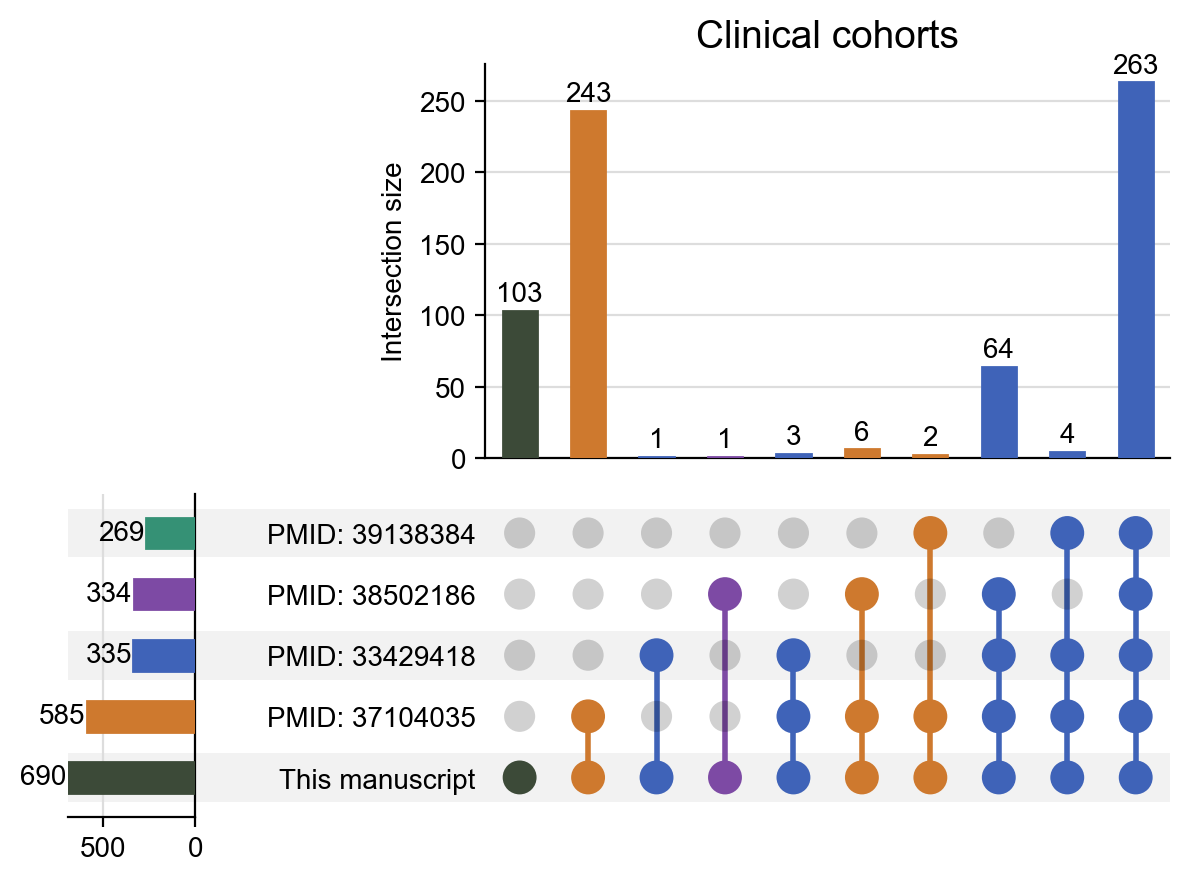

In [58]:
upset = upsetplot.UpSet(up_df, subset_size="count", show_counts=True)

for p in papers:
    upset.style_categories(p.label, bar_facecolor=p.color)
    upset.style_subsets(present=p.label, facecolor=p.color)

p = upset.plot()
for c in p['totals'].get_children():
    if isinstance(c, mpl.patches.Rectangle):
        c.set_zorder(5)
p['totals'].grid(axis='x', color='#ddd')
p['intersections'].grid(axis='y', color='#ddd')
p['totals'].spines['right'].set_visible(True)
p['intersections'].spines['bottom'].set_visible(True)
p['intersections'].set_title('Clinical cohorts', size=14)
p['totals'].figure.savefig('00_figures/11_upset_clinical.pdf')

In [ ]:
up_df = upsetplot.from_contents({
    paper.label: paper.study_ids[paper.data_types['flow_data'].eq(1)]
    for paper
    in papers
    if 'flow_data' in paper.data_types
})

In [60]:
up_df = up_df.loc[up_df.index.get_level_values('This manuscript')]

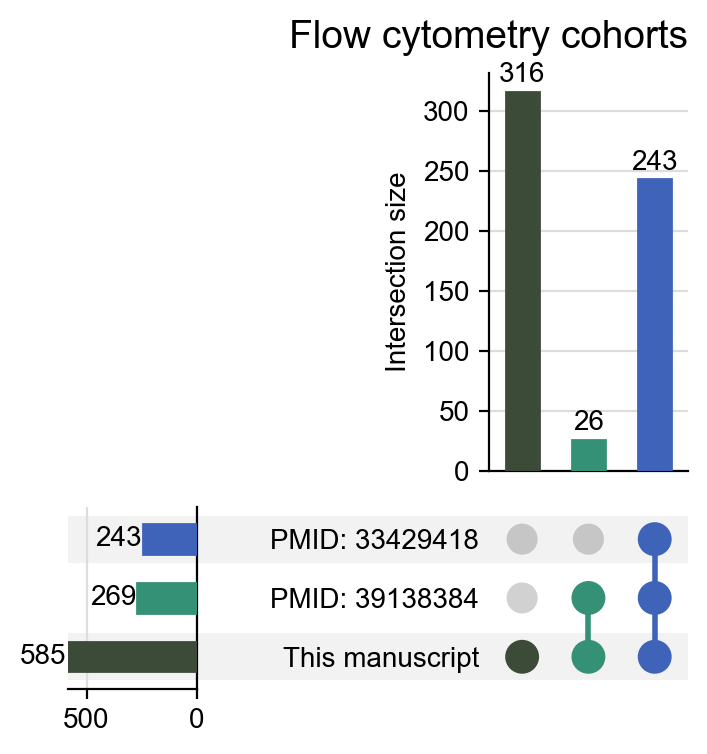

In [64]:
upset = upsetplot.UpSet(up_df, subset_size="count", show_counts=True)

for p in papers:
    if 'flow_data' in p.data_types:
        upset.style_categories(p.label, bar_facecolor=p.color)
        upset.style_subsets(present=p.label, facecolor=p.color)

p = upset.plot()
for c in p['totals'].get_children():
    if isinstance(c, mpl.patches.Rectangle):
        c.set_zorder(5)
p['totals'].grid(axis='x', color='#ddd')
p['intersections'].grid(axis='y', color='#ddd')
p['totals'].spines['right'].set_visible(True)
p['intersections'].spines['bottom'].set_visible(True)
p['intersections'].set_title('Flow cytometry cohorts', size=14, ha='right', x=1, va='bottom')
p['totals'].figure.savefig('00_figures/11_upset_flow.pdf')

In [ ]:
up_df = upsetplot.from_contents({
    paper.label: paper.study_ids[paper.data_types['scRNA_data'].eq(1)]
    for paper
    in papers
    if 'scRNA_data' in paper.data_types
})

In [67]:
up_df = up_df.loc[up_df.index.get_level_values('This manuscript')]

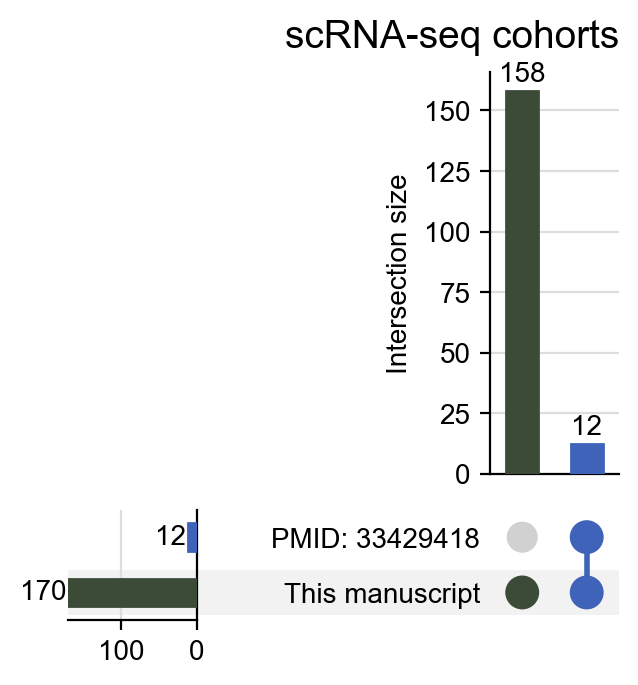

In [68]:
upset = upsetplot.UpSet(up_df, subset_size="count", show_counts=True)

for p in papers:
    if 'scRNA_data' in p.data_types:
        upset.style_categories(p.label, bar_facecolor=p.color)
        upset.style_subsets(present=p.label, facecolor=p.color)

p = upset.plot()
for c in p['totals'].get_children():
    if isinstance(c, mpl.patches.Rectangle):
        c.set_zorder(5)
p['totals'].grid(axis='x', color='#ddd')
p['intersections'].grid(axis='y', color='#ddd')
p['totals'].spines['right'].set_visible(True)
p['intersections'].spines['bottom'].set_visible(True)
p['intersections'].set_title('scRNA-seq cohorts', size=14, ha='right', x=1, va='bottom')
p['totals'].figure.savefig('00_figures/11_upset_scrnaseq.pdf')